# Customer Churn Prediction Using Machine Learning
## Telecom Customer Churn Dataset Analysis

This notebook builds a complete ML pipeline to predict customer churn in a telecom company.

In [33]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Task 1: Data Loading and Understanding

In [34]:

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

In [35]:

print("Column Names and Data Types:")
print(df.dtypes)
print("\n" + "="*80)
print("\nBasic Statistics:")
print(df.describe())

Column Names and Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Basic Statistics:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000

In [36]:
column_explanation = """
CUSTOMER DEMOGRAPHICS:
- customerID: Unique identifier for each customer
- gender: Customer's gender (Male/Female)
- SeniorCitizen: Whether customer is a senior citizen (1=Yes, 0=No)
- Partner: Whether customer has a partner (Yes/No)
- Dependents: Whether customer has dependents (Yes/No)

SERVICE & USAGE:
- tenure: Number of months customer has been with the company
- PhoneService: Whether customer has phone service (Yes/No)
- MultipleLines: Whether customer has multiple phone lines (Yes/No/No phone service)
- InternetService: Type of internet service (DSL/Fiber optic/No)
- OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies:
  Whether customer has these add-on services (Yes/No/No internet service)

CONTRACT & BILLING:
- Contract: Type of contract (Month-to-month/One year/Two year)
- PaperlessBilling: Whether customer uses paperless billing (Yes/No)
- PaymentMethod: How customer pays (Electronic check/Mailed check/Bank transfer/Credit card)
- MonthlyCharges: Monthly charges in dollars
- TotalCharges: Total charges accumulated by customer

TARGET VARIABLE:
- Churn: Whether customer left the company (Yes/No)
"""
print(column_explanation)


CUSTOMER DEMOGRAPHICS:
- customerID: Unique identifier for each customer
- gender: Customer's gender (Male/Female)
- SeniorCitizen: Whether customer is a senior citizen (1=Yes, 0=No)
- Partner: Whether customer has a partner (Yes/No)
- Dependents: Whether customer has dependents (Yes/No)

SERVICE & USAGE:
- tenure: Number of months customer has been with the company
- PhoneService: Whether customer has phone service (Yes/No)
- MultipleLines: Whether customer has multiple phone lines (Yes/No/No phone service)
- InternetService: Type of internet service (DSL/Fiber optic/No)
- OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies:
  Whether customer has these add-on services (Yes/No/No internet service)

CONTRACT & BILLING:
- Contract: Type of contract (Month-to-month/One year/Two year)
- PaperlessBilling: Whether customer uses paperless billing (Yes/No)
- PaymentMethod: How customer pays (Electronic check/Mailed check/Bank transfer/Credit card)
- Mont

## Task 2: Data Preprocessing

In [37]:
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print(f"\nData Type Check:")
print(df.dtypes)

Missing Values:
No missing values found

Duplicate Rows: 0

Data Type Check:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [38]:
print("Sample of TotalCharges column:")
print(df['TotalCharges'].head(10))
print(f"\nTotalCharges data type: {df['TotalCharges'].dtype}")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"\nAfter conversion:")
print(f"TotalCharges data type: {df['TotalCharges'].dtype}")
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

Sample of TotalCharges column:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

TotalCharges data type: object

After conversion:
TotalCharges data type: float64
Missing values in TotalCharges: 11


In [39]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

print(f"Missing values after imputation: {df['TotalCharges'].isnull().sum()}")
print(f"\nData quality check complete.")
print(f"Dataset shape: {df.shape}")

Missing values after imputation: 0

Data quality check complete.
Dataset shape: (7043, 21)


In [40]:
df = df.drop('customerID', axis=1)

print("Preprocessing Summary:")
print("1. Converted TotalCharges to numeric (was object type)")
print("2. Imputed missing TotalCharges values with MonthlyCharges for new customers")
print("3. Removed customerID column (not relevant for prediction)")
print(f"\nFinal dataset shape: {df.shape}")

Preprocessing Summary:
1. Converted TotalCharges to numeric (was object type)
2. Imputed missing TotalCharges values with MonthlyCharges for new customers
3. Removed customerID column (not relevant for prediction)

Final dataset shape: (7043, 20)


## Task 3: Exploratory Data Analysis (EDA)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


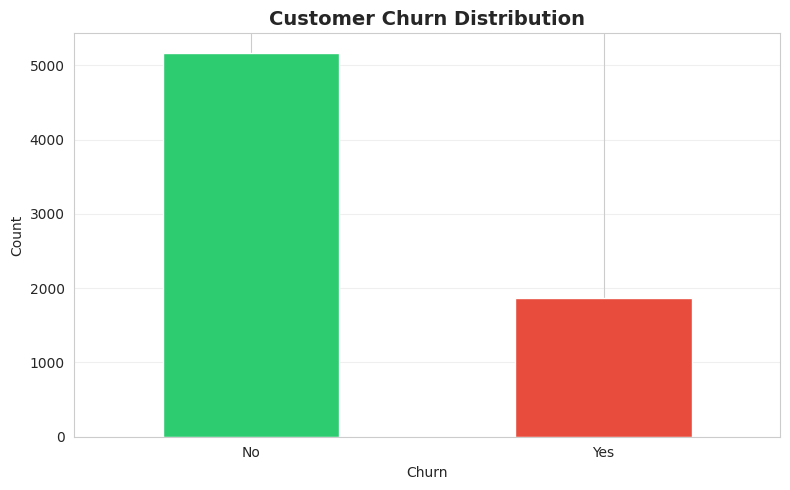


Dataset is imbalanced: 26.5% churn vs 73.5% retained


In [41]:
print("Churn Distribution:")
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {(churn_counts['Yes'] / len(df) * 100):.2f}%")

plt.figure(figsize=(8, 5))
churn_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDataset is imbalanced: {(churn_counts['Yes'] / len(df) * 100):.1f}% churn vs {(churn_counts['No'] / len(df) * 100):.1f}% retained")

Churn by Contract Type:
Churn             No   Yes   All
Contract                        
Month-to-month  2220  1655  3875
One year        1307   166  1473
Two year        1647    48  1695
All             5174  1869  7043

Churn Rate by Contract Type:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


<Figure size 1000x500 with 0 Axes>

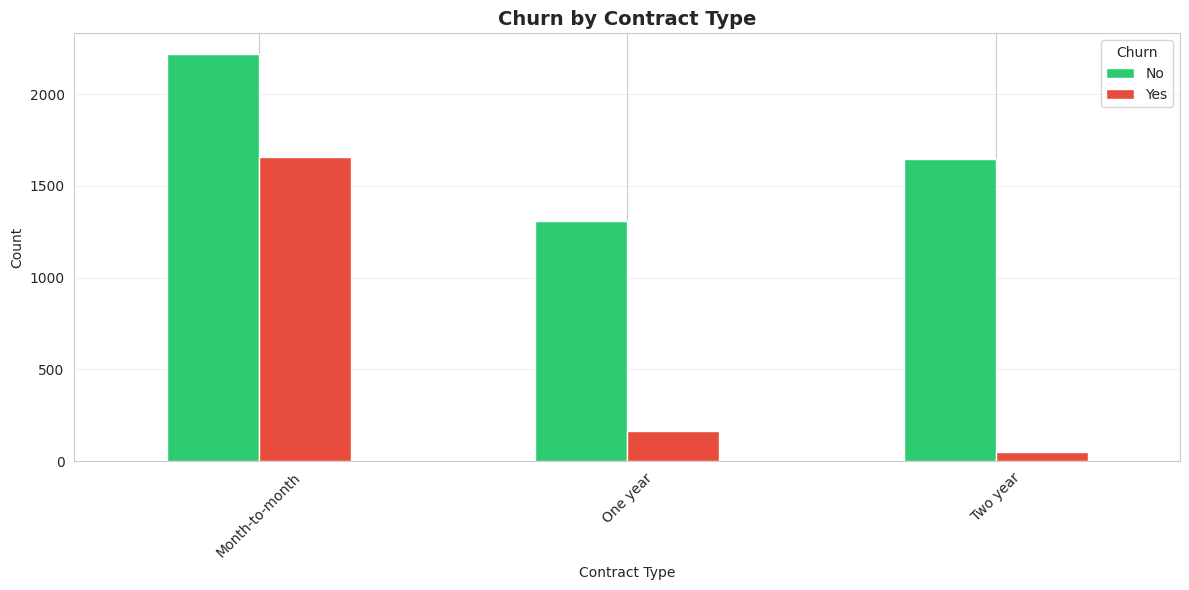

In [42]:
print("Churn by Contract Type:")
contract_churn = pd.crosstab(df['Contract'], df['Churn'], margins=True)
print(contract_churn)

contract_churn_pct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print("\nChurn Rate by Contract Type:")
print(contract_churn_pct.round(2))

plt.figure(figsize=(10, 5))
contract_churn.iloc[:-1, :-1].plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Churn')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Churn by Internet Service Type:
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


<Figure size 1000x500 with 0 Axes>

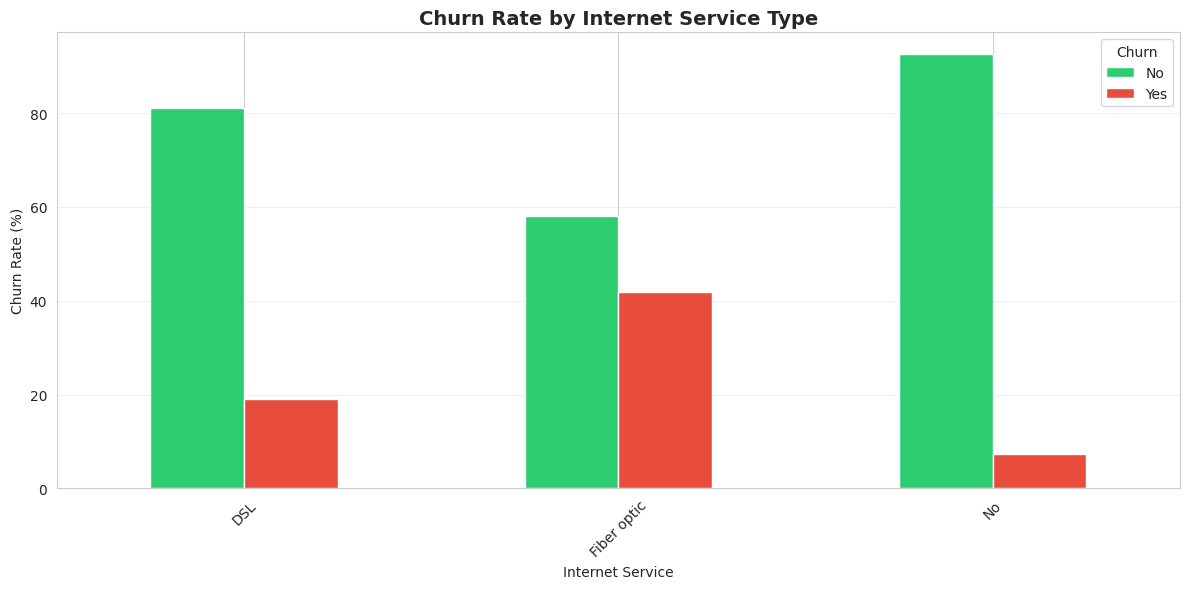

In [43]:
print("Churn by Internet Service Type:")
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(internet_churn.round(2))

plt.figure(figsize=(10, 5))
internet_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Churn')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Tenure Statistics by Churn:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


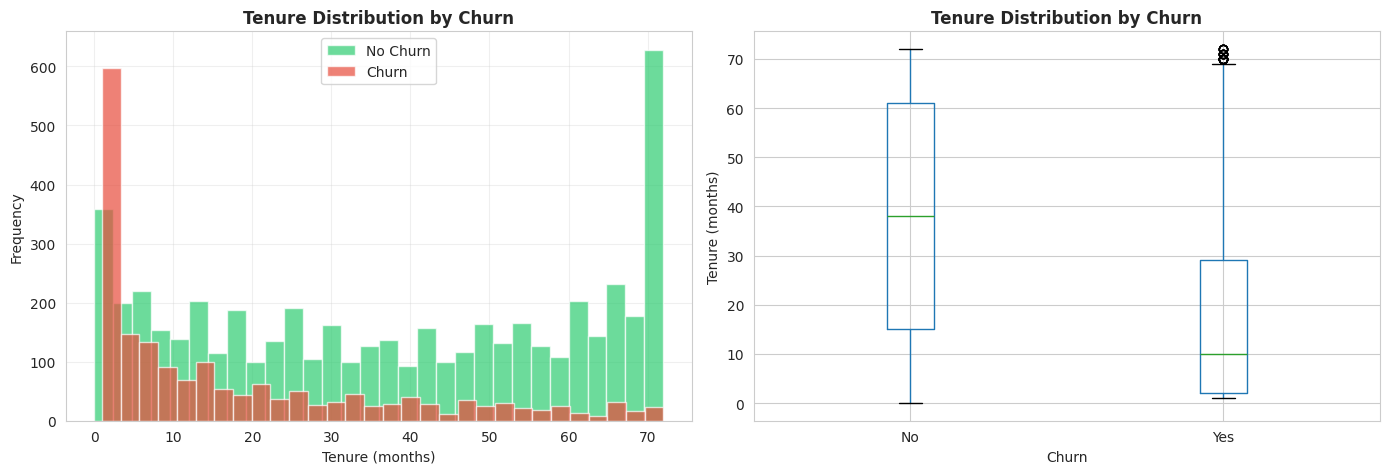

In [44]:
print("Tenure Statistics by Churn:")
print(df.groupby('Churn')['tenure'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Churn'] == 'No']['tenure'].hist(bins=30, ax=axes[0], color='#2ecc71', alpha=0.7, label='No Churn')
df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, ax=axes[0], color='#e74c3c', alpha=0.7, label='Churn')
axes[0].set_title('Tenure Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

df.boxplot(column='tenure', by='Churn', ax=axes[1])
axes[1].set_title('Tenure Distribution by Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')
plt.suptitle('')
plt.tight_layout()
plt.show()

Monthly Charges Statistics by Churn:
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


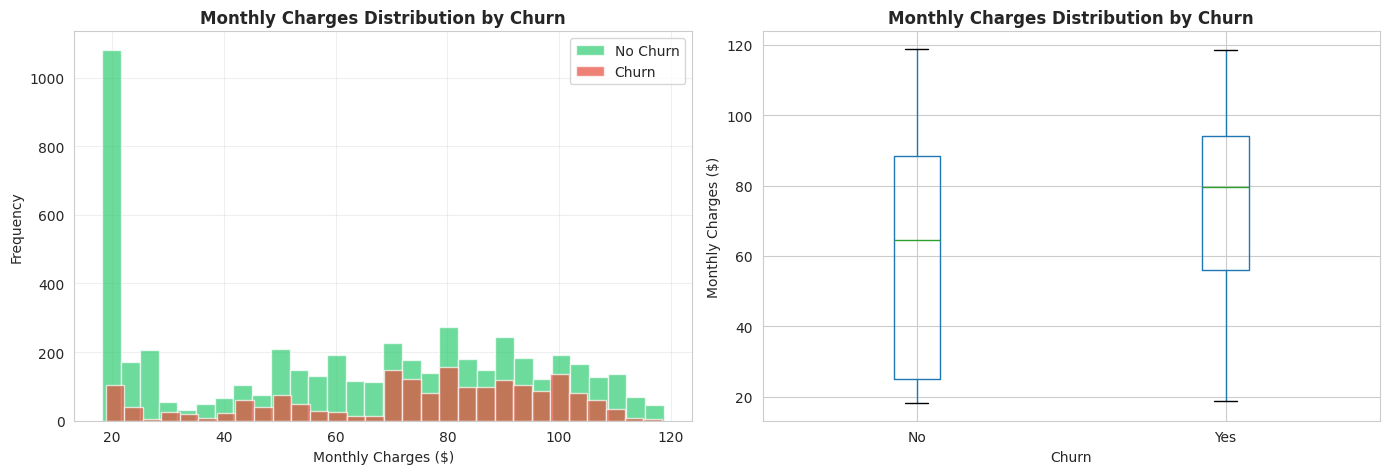

In [45]:
print("Monthly Charges Statistics by Churn:")
print(df.groupby('Churn')['MonthlyCharges'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Churn'] == 'No']['MonthlyCharges'].hist(bins=30, ax=axes[0], color='#2ecc71', alpha=0.7, label='No Churn')
df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(bins=30, ax=axes[0], color='#e74c3c', alpha=0.7, label='Churn')
axes[0].set_title('Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Monthly Charges ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

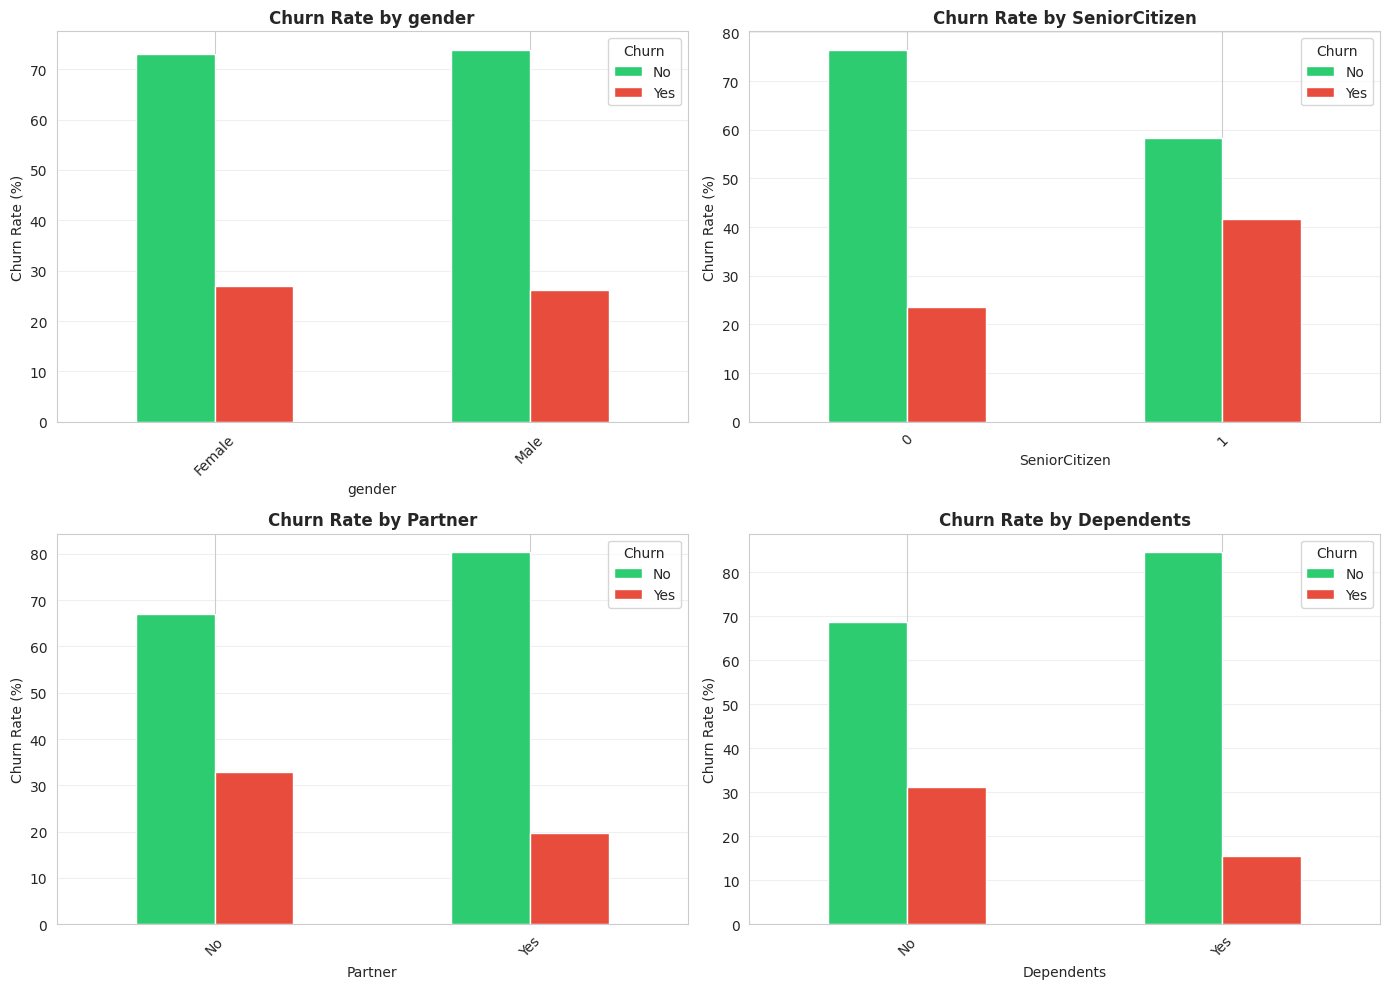

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(['gender', 'SeniorCitizen', 'Partner', 'Dependents']):
    ax = axes[idx // 2, idx % 2]
    churn_by_cat = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    churn_by_cat.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.legend(title='Churn')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Task 4: Feature Engineering and Encoding

In [47]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Target Variable Distribution:")
print(y.value_counts())
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

Target Variable Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Features shape: (7043, 19)
Target shape: (7043,)


In [48]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical Columns ({len(categorical_cols)}):")
print(categorical_cols)
print(f"\nNumerical Columns ({len(numerical_cols)}):")
print(numerical_cols)

Categorical Columns (15):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Columns (4):
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [49]:
binary_cols = ['PhoneService', 'PaperlessBilling']
for col in binary_cols:
    X[col] = (X[col] == 'Yes').astype(int)

print("Converted binary variables to numeric (0/1)")

from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_to_encode = [col for col in categorical_cols if col not in binary_cols]

for col in categorical_to_encode:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Converted binary variables to numeric (0/1)
Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Encoded Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
Encoded InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
Encoded OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded DeviceProtection: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded TechSupport: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded StreamingTV: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded StreamingMovies: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int6

In [50]:
y_encoded = (y == 'Yes').astype(int)

print("Target Variable Encoding:")
print(f"No Churn (Stayed) = 0")
print(f"Churn (Left) = 1")
print(f"\nEncoded target distribution:")
print(y_encoded.value_counts())

print(f"\nFeatures after encoding:")
print(X.head())
print(f"\nFinal features shape: {X.shape}")

Target Variable Encoding:
No Churn (Stayed) = 0
Churn (Left) = 1

Encoded target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Features after encoding:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0  

## Task 5: Training and Testing

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set churn distribution:")
print(y_train.value_counts())
print(f"\nTesting set churn distribution:")
print(y_test.value_counts())


Training set size: 5634 samples
Testing set size: 1409 samples

Training set churn distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing set churn distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

Features scaled using StandardScaler
Scaled training data shape: (5634, 19)
Scaled testing data shape: (1409, 19)


In [53]:
print("="*80)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*80)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

print("Model trained successfully")
print(f"Number of features: {lr_model.n_features_in_}")

MODEL 1: LOGISTIC REGRESSION
Model trained successfully
Number of features: 19


In [54]:
print("="*80)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*80)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Model trained successfully")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Max depth: {rf_model.max_depth}")

MODEL 2: RANDOM FOREST CLASSIFIER
Model trained successfully
Number of trees: 100
Max depth: 15


## Task 6: Model Evaluation

In [55]:
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

print("Predictions generated for both models")

Predictions generated for both models


In [56]:
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    print(f"\nTrue Negatives (TN):  {cm[0][0]} - Correctly predicted non-churn customers")
    print(f"False Positives (FP): {cm[0][1]} - Non-churn predicted as churn")
    print(f"False Negatives (FN): {cm[1][0]} - Churn predicted as non-churn")
    print(f"True Positives (TP):  {cm[1][1]} - Correctly predicted churn customers")

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

results = []
results.append(evaluate_model(y_test, lr_pred, 'Logistic Regression'))
results.append(evaluate_model(y_test, rf_pred, 'Random Forest'))


MODEL: Logistic Regression
Accuracy:  0.7984 (79.84%)
Precision: 0.6406
Recall:    0.5481
F1-Score:  0.5908

Confusion Matrix:
[[920 115]
 [169 205]]

True Negatives (TN):  920 - Correctly predicted non-churn customers
False Positives (FP): 115 - Non-churn predicted as churn
False Negatives (FN): 169 - Churn predicted as non-churn
True Positives (TP):  205 - Correctly predicted churn customers

MODEL: Random Forest
Accuracy:  0.7857 (78.57%)
Precision: 0.6200
Recall:    0.4973
F1-Score:  0.5519

Confusion Matrix:
[[921 114]
 [188 186]]

True Negatives (TN):  921 - Correctly predicted non-churn customers
False Positives (FP): 114 - Non-churn predicted as churn
False Negatives (FN): 188 - Churn predicted as non-churn
True Positives (TP):  186 - Correctly predicted churn customers



MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.798439   0.640625 0.548128  0.590778
      Random Forest  0.785664   0.620000 0.497326  0.551929

Best Model by F1-Score: Logistic Regression
Note: F1 balances precision and recall, which matters here because the classes are imbalanced.


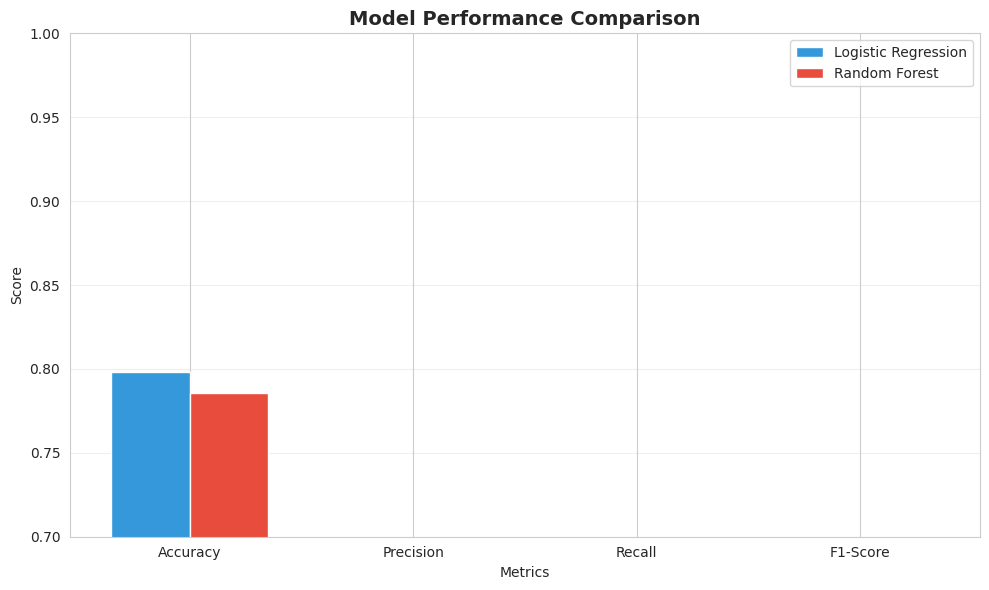



Best Model by F1-Score: Logistic Regression
Note: F1 balances precision and recall, which matters here because the classes are imbalanced.


In [57]:
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

ax.bar(x - width/2, results_df.iloc[0][metrics], width, label='Logistic Regression', color='#3498db')
ax.bar(x + width/2, results_df.iloc[1][metrics], width, label='Random Forest', color='#e74c3c')

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBest Model by F1-Score:", results_df.loc[results_df['F1-Score'].idxmax(), 'Model'])
print("Note: F1 balances precision and recall, which matters here because the classes are imbalanced.")



Top 10 Most Important Features (Random Forest):
        Feature  Importance
   TotalCharges    0.174929
 MonthlyCharges    0.173806
         tenure    0.160716
       Contract    0.086940
 OnlineSecurity    0.053000
  PaymentMethod    0.050511
    TechSupport    0.046368
InternetService    0.029030
   OnlineBackup    0.027565
         gender    0.026038


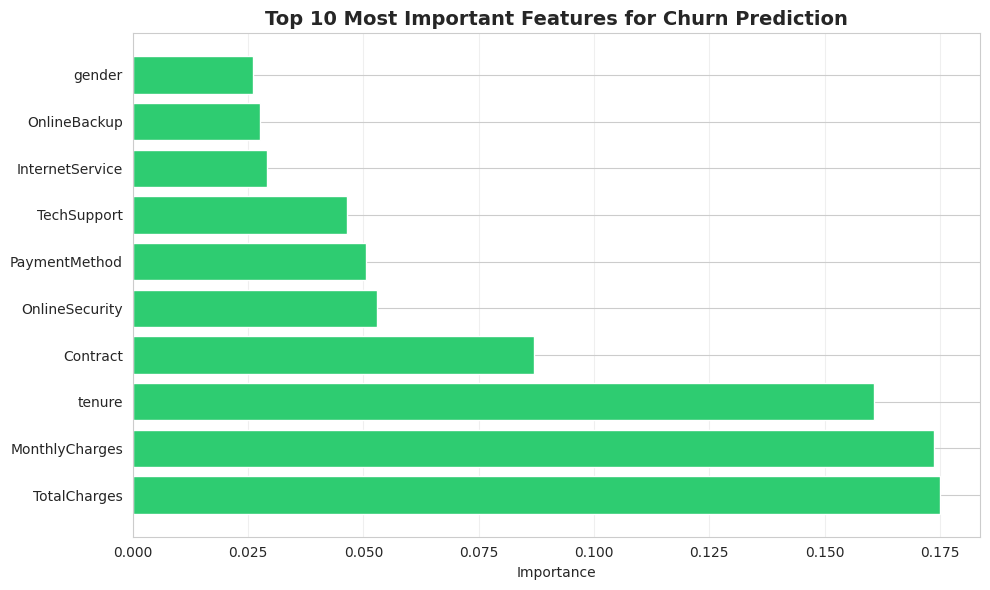

In [58]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (Random Forest):")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'], color='#2ecc71')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features for Churn Prediction', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Task 7: Application / Prediction on Sample Data

In [59]:
sample_customers = pd.DataFrame({
    'gender': ['Male', 'Female', 'Male'],
    'SeniorCitizen': [0, 1, 0],
    'Partner': ['Yes', 'No', 'Yes'],
    'Dependents': ['No', 'No', 'Yes'],
    'tenure': [2, 60, 12],
    'PhoneService': ['Yes', 'Yes', 'No'],
    'MultipleLines': ['No', 'Yes', 'No phone service'],
    'InternetService': ['Fiber optic', 'DSL', 'DSL'],
    'OnlineSecurity': ['No', 'Yes', 'No'],
    'OnlineBackup': ['No', 'Yes', 'No'],
    'DeviceProtection': ['No', 'Yes', 'No'],
    'TechSupport': ['No', 'Yes', 'Yes'],
    'StreamingTV': ['No', 'Yes', 'No'],
    'StreamingMovies': ['No', 'Yes', 'No'],
    'Contract': ['Month-to-month', 'Two year', 'One year'],
    'PaperlessBilling': ['Yes', 'No', 'Yes'],
    'PaymentMethod': ['Electronic check', 'Bank transfer (automatic)', 'Credit card (automatic)'],
    'MonthlyCharges': [70.7, 56.15, 49.95],
    'TotalCharges': [151.65, 3487.95, 587.45]
})

print("Sample Customers for Prediction:")
print(sample_customers)
print("\n" + "="*80)

Sample Customers for Prediction:
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0    Male              0     Yes         No       2          Yes   
1  Female              1      No         No      60          Yes   
2    Male              0     Yes        Yes      12           No   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0                No     Fiber optic             No           No   
1               Yes             DSL            Yes          Yes   
2  No phone service             DSL             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes         Yes         Yes             Yes        Two year   
2               No         Yes          No              No        One year   

  PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges  
0              Yes           Elect

In [60]:
X_sample = sample_customers.copy()

for col in binary_cols:
    X_sample[col] = (X_sample[col] == 'Yes').astype(int)

for col in label_encoders.keys():
    X_sample[col] = label_encoders[col].transform(X_sample[col])

print("Sample data after preprocessing:")
print(X_sample)

Sample data after preprocessing:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       1              0        1           0       2             1   
1       0              1        0           0      60             1   
2       1              0        1           1      12             0   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              0                1               0             0   
1              2                0               2             2   
2              1                0               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 2            2            2                2         2   
2                 0            2            0                0         1   

   PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  
0                 1              2       

In [61]:
rf_predictions = rf_model.predict(X_sample)
rf_probabilities = rf_model.predict_proba(X_sample)

print("\nPREDICTIONS ON SAMPLE CUSTOMERS")
print("="*80)

prediction_results = pd.DataFrame({
    'Customer': ['Customer 1', 'Customer 2', 'Customer 3'],
    'Monthly Charges': sample_customers['MonthlyCharges'],
    'Tenure (months)': sample_customers['tenure'],
    'Contract': sample_customers['Contract'],
    'Internet Service': sample_customers['InternetService'],
    'Churn Prediction': ['Churn' if pred == 1 else 'No Churn' for pred in rf_predictions],
    'Churn Probability': rf_probabilities[:, 1],
    'Confidence': np.max(rf_probabilities, axis=1)
})

print(prediction_results.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
for idx, row in prediction_results.iterrows():
    print(f"\n{row['Customer']}:")
    print(f"  - Prediction: {row['Churn Prediction']}")
    print(f"  - Churn Probability: {row['Churn Probability']:.2%}")
    print(f"  - Confidence: {row['Confidence']:.2%}")
    if row['Churn Prediction'] == 'Churn':
        print(f"  - Action: This customer is at HIGH RISK of leaving. Consider retention strategies.")
    else:
        print(f"  - Action: This customer is likely to stay. Monitor regularly.")


PREDICTIONS ON SAMPLE CUSTOMERS
  Customer  Monthly Charges  Tenure (months)       Contract Internet Service Churn Prediction  Churn Probability  Confidence
Customer 1            70.70                2 Month-to-month      Fiber optic         No Churn           0.474753    0.525247
Customer 2            56.15               60       Two year              DSL         No Churn           0.090455    0.909545
Customer 3            49.95               12       One year              DSL         No Churn           0.160000    0.840000

INTERPRETATION:

Customer 1:
  - Prediction: No Churn
  - Churn Probability: 47.48%
  - Confidence: 52.52%
  - Action: This customer is likely to stay. Monitor regularly.

Customer 2:
  - Prediction: No Churn
  - Churn Probability: 9.05%
  - Confidence: 90.95%
  - Action: This customer is likely to stay. Monitor regularly.

Customer 3:
  - Prediction: No Churn
  - Churn Probability: 16.00%
  - Confidence: 84.00%
  - Action: This customer is likely to stay. Monit

## Summary and Conclusions

In [62]:
summary = """
    CUSTOMER CHURN PREDICTION - FINAL SUMMARY
    =========================================

    DATASET OVERVIEW:
    - Total customers: 7,043
    - Features: 19 (after dropping customerID)
    - Target variable: Churn (Yes/No)
    - Churn rate: 26.54% of customers left the company

    KEY FINDINGS FROM EDA:
    1. Month-to-month contracts have much higher churn (42.7%) vs two-year contracts (2.8%)
    2. Fiber optic internet customers churn more (41.9%) than DSL customers (19.0%)
    3. Shorter tenure is associated with higher churn
    4. Churners tend to have higher monthly charges

    MODEL PERFORMANCE (test set, 1,409 customers):
    Logistic Regression: Accuracy 79.84%, Precision 64.06%, Recall 54.81%, F1 0.5908
    Random Forest:       Accuracy 78.57%, Precision 62.00%, Recall 49.73%, F1 0.5519
    Best Model by F1: Logistic Regression (the simpler model wins on this data)

    TOP 5 FEATURES (Random Forest importance):
    1. TotalCharges  2. MonthlyCharges  3. tenure  4. Contract  5. OnlineSecurity

    BUSINESS RECOMMENDATIONS:
    1. Focus retention efforts on month-to-month contract customers
    2. Offer incentives for upgrading to longer-term contracts
    3. Investigate why fiber optic customers churn more (service quality? pricing?)
    4. Monitor customers in their first months of tenure

    MODEL LIMITATIONS:
    1. Recall is roughly 50-55%: the model misses about half of actual churners
    2. Dataset is imbalanced (73.5% stay vs 26.5% churn); no resampling or threshold tuning was applied
    3. No hyperparameter tuning or cross-validation
    4. May not generalize to different regions or time periods

    NEXT STEPS:
    1. Try class weighting / SMOTE and tune the decision threshold to improve recall
    2. Add cross-validation and hyperparameter search
    3. Try gradient boosting (XGBoost / LightGBM)
    4. Collect more behavioral data (support tickets, usage patterns)
"""

print(summary)


    CUSTOMER CHURN PREDICTION - FINAL SUMMARY

    DATASET OVERVIEW:
    - Total customers: 7,043
    - Features: 19 (after dropping customerID)
    - Target variable: Churn (Yes/No)
    - Churn rate: 26.54% of customers left the company

    KEY FINDINGS FROM EDA:
    1. Month-to-month contracts have much higher churn (42.7%) vs two-year contracts (2.8%)
    2. Fiber optic internet customers churn more (41.9%) than DSL customers (19.0%)
    3. Shorter tenure is associated with higher churn
    4. Churners tend to have higher monthly charges

    MODEL PERFORMANCE (test set, 1,409 customers):
    Logistic Regression: Accuracy 79.84%, Precision 64.06%, Recall 54.81%, F1 0.5908
    Random Forest:       Accuracy 78.57%, Precision 62.00%, Recall 49.73%, F1 0.5519
    Best Model by F1: Logistic Regression (the simpler model wins on this data)

    TOP 5 FEATURES (Random Forest importance):
    1. TotalCharges  2. MonthlyCharges  3. tenure  4. Contract  5. OnlineSecurity

    BUSINESS RECOM